# Notebook Objective

# 02 Exploratory Data Analysis

This notebook explores the NASA C-MAPSS Turbofan Engine Degradation Dataset after the raw files have been imported and their basic structure has been verified.

The goal of this notebook is to understand the degradation data before building preprocessing and modeling pipelines.

The main objectives are:

- inspect the selected dataset subset and compare it with the other C-MAPSS subsets
- analyze engine lifetime distributions
- construct the Remaining Useful Life (RUL) target for exploratory analysis
- compare short-lived and long-lived engines
- inspect operational settings and their variability
- identify constant or low-variance sensor signals
- analyze relationships between sensor values and RUL
- visualize selected sensor trajectories over engine lifetime
- derive first sensor candidates and preprocessing decisions for later notebooks

This notebook is exploratory. It may identify transformations such as dropping constant sensors or using capped RUL values, but final preprocessing decisions are implemented in later notebooks or reusable project modules.

# Imports and Project Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.data_loading import (
    load_cmapss_dataset,
    load_all_cmapss_datasets,
    DATASET_IDS,
    SETTING_NAMES,
    SENSOR_NAMES
)

from src.config import load_config, flatten_config


# Load Dataset

FD001 is used as the initial dataset because it contains one operating condition and one fault mode. This makes it suitable for the first exploratory analysis and for building an initial RUL prediction pipeline.

The notebook can be applied to another subset by changing `CURRENT_DATASET`.

In [3]:
config = load_config()
flat_config = flatten_config(config)

CURRENT_DATASET = flat_config["CURRENT_DATASET"]
RUL_CAP = flat_config["RUL_CAP"]
VALIDATION_SIZE = flat_config["VALIDATION_SIZE"]
RANDOM_STATE = flat_config["RANDOM_STATE"]
WINDOW_SIZE = flat_config["WINDOW_SIZE"]
WINDOW_STEP = flat_config["WINDOW_STEP"]

index_cols = flat_config["INDEX_COLS"]
target_cols = flat_config["TARGET_COLS"]
helper_cols = flat_config["HELPER_COLS"]
target_col = flat_config["TARGET_COL"]

model_config = config["models"]
conformal_config = config["conformal"]
simulation_config = config["simulation"]

if CURRENT_DATASET not in DATASET_IDS:
    raise ValueError(f"Unknown dataset: {CURRENT_DATASET}")

df_train, df_test, df_test_rul = load_cmapss_dataset(CURRENT_DATASET)

print(f"Current dataset: {CURRENT_DATASET}")
print(f"Training data shape: {df_train.shape}")
print(f"Test data shape:     {df_test.shape}")
print(f"Test RUL shape:      {df_test_rul.shape}")


Current dataset: FD001
Training data shape: (20631, 26)
Test data shape:     (13096, 26)
Test RUL shape:      (100, 1)


In [4]:
df_train.head()

,engine,cycle,setting_1,setting_2,setting_3,T2 (Fan inlet temperature),T24 (LPC outlet temperature),T30 (HPC outlet temperature),T50 (LPT outlet temperature),P2 (Fan inlet pressure),P15 (bypass duct pressure),P30 (HPC outlet pressure),Nf (Physical fan speed),Nc (Physical core speed),epr (Engine pressure ratio (P50/P2)),Ps30 (Static pressure at HPC outlet),phi (Ratio of fuel flow to Ps30),NRf (Corrected fan speed),NRc (Corrected core speed),BPR (Bypass ratio),farB (Fuel-air ratio),htBleed (Bleed enthalpy),Nf_dmd (Demanded fan speed),PCNfr_dmd (Demanded corrected fan speed),W31 (HPT Cool air flow),W32 (LPT Cool air flow)
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
df_test.head()

,engine,cycle,setting_1,setting_2,setting_3,T2 (Fan inlet temperature),T24 (LPC outlet temperature),T30 (HPC outlet temperature),T50 (LPT outlet temperature),P2 (Fan inlet pressure),P15 (bypass duct pressure),P30 (HPC outlet pressure),Nf (Physical fan speed),Nc (Physical core speed),epr (Engine pressure ratio (P50/P2)),Ps30 (Static pressure at HPC outlet),phi (Ratio of fuel flow to Ps30),NRf (Corrected fan speed),NRc (Corrected core speed),BPR (Bypass ratio),farB (Fuel-air ratio),htBleed (Bleed enthalpy),Nf_dmd (Demanded fan speed),PCNfr_dmd (Demanded corrected fan speed),W31 (HPT Cool air flow),W32 (LPT Cool air flow)
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,21.61,553.90,2388.04,9050.17,1.3,47.20,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,21.61,554.85,2388.01,9054.42,1.3,47.50,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,21.61,554.11,2388.05,9056.96,1.3,47.50,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,21.61,554.07,2388.03,9045.29,1.3,47.28,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,21.61,554.16,2388.01,9044.55,1.3,47.31,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [6]:
df_test_rul.head()

,RUL
0,112
1,98
2,69
3,82
4,91


# Dataset Overview Across All Subsets

Before focusing on FD001, the four available C-MAPSS subsets are compared in terms of size, number of engines and observed cycle lengths.

In [7]:
datasets = load_all_cmapss_datasets()

overview_rows = []

for dataset_id, data in datasets.items():
    train_i = data["train"]
    test_i = data["test"]
    rul_i = data["test_RUL"]
    
    train_lifetimes_i = train_i.groupby("engine")["cycle"].max()
    test_lengths_i = test_i.groupby("engine")["cycle"].max()
    
    overview_rows.append({
        "dataset": dataset_id,
        "train_rows": train_i.shape[0],
        "test_rows": test_i.shape[0],
        "train_engines": train_i["engine"].nunique(),
        "test_engines": test_i["engine"].nunique(),
        "rul_values": rul_i.shape[0],
        "train_min_cycles": train_lifetimes_i.min(),
        "train_mean_cycles": train_lifetimes_i.mean(),
        "train_max_cycles": train_lifetimes_i.max(),
        "test_min_cycles": test_lengths_i.min(),
        "test_mean_cycles": test_lengths_i.mean(),
        "test_max_cycles": test_lengths_i.max(),
    })

dataset_overview = pd.DataFrame(overview_rows)
dataset_overview

,dataset,train_rows,test_rows,train_engines,test_engines,rul_values,train_min_cycles,train_mean_cycles,train_max_cycles,test_min_cycles,test_mean_cycles,test_max_cycles
0,FD001,20631,13096,100,100,100,128,206.310000,362,31,130.960000,303
1,FD002,53759,33991,260,259,259,128,206.765385,378,21,131.239382,367
2,FD003,24720,16596,100,100,100,145,247.200000,525,38,165.960000,475
3,FD004,61249,41214,249,248,248,128,245.979920,543,19,166.185484,486


# Basic Quality Checks

The dataset is checked for missing values, duplicate rows and basic structural consistency.

In [8]:
def basic_quality_report(df, name):
    report = {
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "engines": df["engine"].nunique() if "engine" in df.columns else np.nan,
        "missing_values": df.isna().sum().sum(),
        "duplicate_rows": df.duplicated().sum()
    }
    
    return pd.DataFrame(report, index=[0])


quality_report = pd.concat([
    basic_quality_report(df_train, "train"),
    basic_quality_report(df_test, "test"),
    basic_quality_report(df_test_rul, "test_rul")
], ignore_index=True)

quality_report

,dataset,rows,columns,engines,missing_values,duplicate_rows
0,train,20631,26,100.0,0,0
1,test,13096,26,100.0,0,0
2,test_rul,100,1,NaN,0,29


In [9]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
engine,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
T2 (Fan inlet temperature),20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
T24 (LPC outlet temperature),20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
T30 (HPC outlet temperature),20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
T50 (LPT outlet temperature),20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
P2 (Fan inlet pressure),20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


# Engine Lifetime Analysis

The training trajectories run until failure. Therefore, the maximum observed cycle per engine corresponds to the engine lifetime. This section analyzes the distribution of engine lifetimes in the selected subset.

In [10]:
train_lifetimes = (
    df_train
    .groupby("engine")["cycle"]
    .max()
    .reset_index()
    .rename(columns={"cycle": "lifetime_cycles"})
)

train_lifetimes.describe()

,engine,lifetime_cycles
count,100.000000,100.000000
mean,50.500000,206.310000
std,29.011492,46.342749
min,1.000000,128.000000
25%,25.750000,177.000000
50%,50.500000,199.000000
75%,75.250000,229.250000
max,100.000000,362.000000


In [11]:
lifetime_summary = pd.DataFrame({
    "min_lifetime": [train_lifetimes["lifetime_cycles"].min()],
    "mean_lifetime": [train_lifetimes["lifetime_cycles"].mean()],
    "median_lifetime": [train_lifetimes["lifetime_cycles"].median()],
    "max_lifetime": [train_lifetimes["lifetime_cycles"].max()],
    "std_lifetime": [train_lifetimes["lifetime_cycles"].std()],
})

lifetime_summary

,min_lifetime,mean_lifetime,median_lifetime,max_lifetime,std_lifetime
0,128,206.31,199.0,362,46.342749


In [12]:
shortest_lived_engines = train_lifetimes.nsmallest(5, "lifetime_cycles")
longest_lived_engines = train_lifetimes.nlargest(5, "lifetime_cycles")

shortest_lived_engines

,engine,lifetime_cycles
38,39,128
90,91,135
56,57,137
69,70,137
23,24,147


In [13]:
longest_lived_engines

,engine,lifetime_cycles
68,69,362
91,92,341
95,96,336
66,67,313
82,83,293


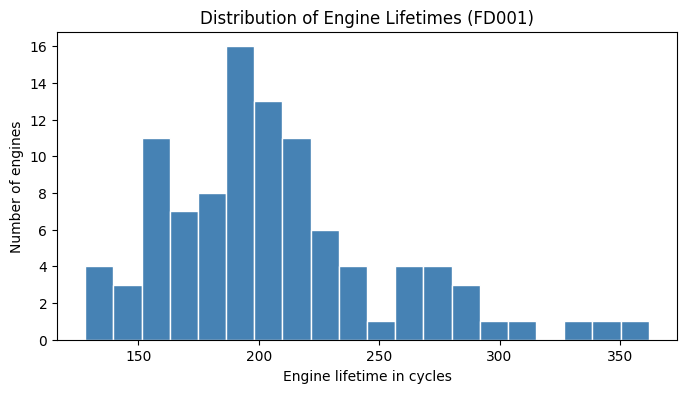

In [14]:
plt.figure(figsize=(8, 4))

plt.hist(
    train_lifetimes["lifetime_cycles"],
    bins=20,
    color="steelblue",
    edgecolor="white"
)

plt.xlabel("Engine lifetime in cycles")
plt.ylabel("Number of engines")
plt.title(f"Distribution of Engine Lifetimes ({CURRENT_DATASET})")
plt.show()

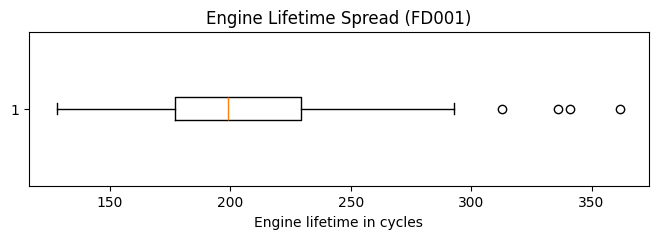

In [15]:
plt.figure(figsize=(8, 2))

plt.boxplot(
    train_lifetimes["lifetime_cycles"],
    vert=False
)

plt.xlabel("Engine lifetime in cycles")
plt.title(f"Engine Lifetime Spread ({CURRENT_DATASET})")
plt.show()

The engine lifetimes in FD001 vary substantially across units. This reflects different initial wear levels and degradation trajectories, even though the subset contains only one operating condition and one fault mode.

Short-lived engines fail after comparatively few cycles, while long-lived engines remain operational for substantially longer. This variation is important for RUL modeling because the model must learn degradation patterns across engines with different total lifetimes.

The shortest- and longest-lived engines identified here can be used in the next step to compare fast and slow degradation behavior.

# RUL target construction for EDA

The training trajectories run until failure. Therefore, the maximum observed cycle of each engine represents the failure point.

For the training data, the Remaining Useful Life is calculated as:

$$
RUL = \text{maximum cycle of engine} - \text{current cycle}
$$

This target is needed for exploratory analysis and later model training.

In [16]:
from src.preprocessing import (
    add_rul_to_training_data,
    add_capped_rul,
    prepare_test_rul
)

In [17]:
df_train_rul = add_rul_to_training_data(df_train)
df_train_rul = add_capped_rul(
    df_train_rul,
    cap=RUL_CAP,
    source_col="RUL",
    target_col="RUL_capped"
)

df_train_rul[["engine", "cycle", "max_cycle", "RUL", "RUL_capped"]].head()


,engine,cycle,max_cycle,RUL,RUL_capped
0,1,1,192,191,125
1,1,2,192,190,125
2,1,3,192,189,125
3,1,4,192,188,125
4,1,5,192,187,125


# Identify constant sensors

In [18]:
constant_features = []

for feature in SETTING_NAMES + SENSOR_NAMES:
    if df_train[feature].nunique() == 1:
        constant_features.append(feature)

constant_feature_summary = pd.DataFrame({
    "feature": constant_features,
    "type": [
        "setting" if feature in SETTING_NAMES else "sensor"
        for feature in constant_features
    ],
    "constant_value": [
        df_train[feature].iloc[0]
        for feature in constant_features
    ]
})

constant_feature_summary

,feature,type,constant_value
0,setting_3,setting,100.00
1,T2 (Fan inlet temperature),sensor,518.67
2,P2 (Fan inlet pressure),sensor,14.62
3,epr (Engine pressure ratio (P50/P2)),sensor,1.30
4,farB (Fuel-air ratio),sensor,0.03
5,Nf_dmd (Demanded fan speed),sensor,2388.00
6,PCNfr_dmd (Demanded corrected fan speed),sensor,100.00


# Create a dataframe without constant sensors

In [19]:
df_train_non_constant = df_train.drop(columns=constant_features)
df_test_non_constant = df_test.drop(columns=constant_features)

df_train_rul_non_constant = df_train_rul.drop(columns=constant_features)

The identified constant features do not contain degradation information within FD001.  
They are kept in the original dataframes for traceability, but removed from separate non-constant copies used for selected visual analyses.

# Sensor Variability Analysis

This section identifies constant and low-variance operational settings and sensor measurements. Such features are unlikely to provide useful degradation information and may later be removed during preprocessing.

In [20]:
feature_variance_rows = []

for feature in SETTING_NAMES + SENSOR_NAMES:
    feature_variance_rows.append({
        "feature": feature,
        "type": "setting" if feature in SETTING_NAMES else "sensor",
        "min": df_train[feature].min(),
        "max": df_train[feature].max(),
        "mean": df_train[feature].mean(),
        "std": df_train[feature].std(),
        "unique_values": df_train[feature].nunique(),
        "is_constant": df_train[feature].nunique() == 1
    })

feature_variance_summary = pd.DataFrame(feature_variance_rows)

feature_variance_summary.sort_values("std")

,feature,type,min,max,mean,std,unique_values,is_constant
2,setting_3,setting,100.0000,100.0000,100.000000,0.000000e+00,1,True
3,T2 (Fan inlet temperature),sensor,518.6700,518.6700,518.670000,0.000000e+00,1,True
21,PCNfr_dmd (Demanded corrected fan speed),sensor,100.0000,100.0000,100.000000,0.000000e+00,1,True
20,Nf_dmd (Demanded fan speed),sensor,2388.0000,2388.0000,2388.000000,0.000000e+00,1,True
12,epr (Engine pressure ratio (P50/P2)),sensor,1.3000,1.3000,1.300000,0.000000e+00,1,True
18,farB (Fuel-air ratio),sensor,0.0300,0.0300,0.030000,3.469531e-18,1,True
7,P2 (Fan inlet pressure),sensor,14.6200,14.6200,14.620000,5.329200e-15,1,True
1,setting_2,setting,-0.0006,0.0006,0.000002,2.930621e-04,13,False
8,P15 (bypass duct pressure),sensor,21.6000,21.6100,21.609803,1.388985e-03,2,False
0,setting_1,setting,-0.0087,0.0087,-0.000009,2.187313e-03,158,False


In [21]:
LOW_VARIANCE_THRESHOLD = 1e-6

feature_variance_summary["is_low_variance"] = (
    feature_variance_summary["std"] <= LOW_VARIANCE_THRESHOLD
)

In [22]:
feature_variance_summary["is_low_information"] = (
    (feature_variance_summary["unique_values"] <= 2)
    | feature_variance_summary["is_constant"]
)

In [23]:
feature_variance_summary.sort_values(["is_constant", "std"], ascending=[False, True])

,feature,type,min,max,mean,std,unique_values,is_constant,is_low_variance,is_low_information
2,setting_3,setting,100.0000,100.0000,100.000000,0.000000e+00,1,True,True,True
3,T2 (Fan inlet temperature),sensor,518.6700,518.6700,518.670000,0.000000e+00,1,True,True,True
12,epr (Engine pressure ratio (P50/P2)),sensor,1.3000,1.3000,1.300000,0.000000e+00,1,True,True,True
20,Nf_dmd (Demanded fan speed),sensor,2388.0000,2388.0000,2388.000000,0.000000e+00,1,True,True,True
21,PCNfr_dmd (Demanded corrected fan speed),sensor,100.0000,100.0000,100.000000,0.000000e+00,1,True,True,True
18,farB (Fuel-air ratio),sensor,0.0300,0.0300,0.030000,3.469531e-18,1,True,True,True
7,P2 (Fan inlet pressure),sensor,14.6200,14.6200,14.620000,5.329200e-15,1,True,True,True
1,setting_2,setting,-0.0006,0.0006,0.000002,2.930621e-04,13,False,False,False
8,P15 (bypass duct pressure),sensor,21.6000,21.6100,21.609803,1.388985e-03,2,False,False,True
0,setting_1,setting,-0.0087,0.0087,-0.000009,2.187313e-03,158,False,False,False


The variability analysis shows that several signals are constant within FD001 and therefore do not provide useful degradation information for this subset.

The constant features are:

- `setting_3`
- `T2 (Fan inlet temperature)`
- `P2 (Fan inlet pressure)`
- `epr (Engine pressure ratio (P50/P2))`
- `farB (Fuel-air ratio)`
- `Nf_dmd (Demanded fan speed)`
- `PCNfr_dmd (Demanded corrected fan speed)`

These variables have only one unique value across all training observations. They should therefore be considered for removal during preprocessing, while the original dataframe remains unchanged during EDA.

`P15 (bypass duct pressure)` is not strictly constant, but it has only two unique values and very low variability. This suggests that it may also contain limited information for RUL prediction in FD001.

The remaining sensors show different levels of variation. In particular, temperature and core-speed related sensors such as `T30`, `T50`, `Nc` and `NRc` vary more strongly and may be more relevant for detecting degradation patterns. However, variance alone does not prove predictive usefulness, so these sensors should later be analyzed together with RUL trends and model-based feature importance.

# Operational Settings Analysis

The C-MAPSS subsets differ in the number of operating conditions. This section inspects the operational settings of the selected subset to verify whether the operating regime is stable or variable.

In [24]:
setting_summary = pd.DataFrame({
    "setting": SETTING_NAMES,
    "min": [df_train[setting].min() for setting in SETTING_NAMES],
    "max": [df_train[setting].max() for setting in SETTING_NAMES],
    "mean": [df_train[setting].mean() for setting in SETTING_NAMES],
    "std": [df_train[setting].std() for setting in SETTING_NAMES],
    "unique_values": [df_train[setting].nunique() for setting in SETTING_NAMES],
})

setting_summary

,setting,min,max,mean,std,unique_values
0,setting_1,-0.0087,0.0087,-0.000009,0.002187,158
1,setting_2,-0.0006,0.0006,0.000002,0.000293,13
2,setting_3,100.0000,100.0000,100.000000,0.000000,1


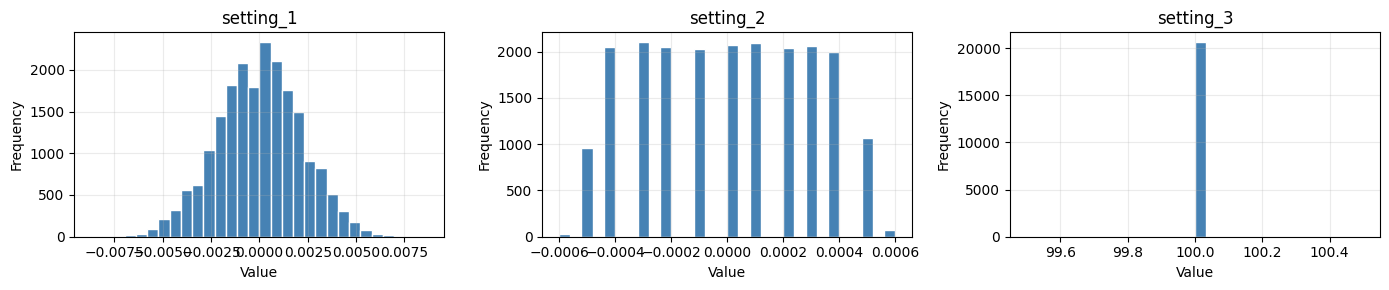

In [25]:
fig, axes = plt.subplots(
    1,
    len(SETTING_NAMES),
    figsize=(14, 3)
)

for ax, setting in zip(axes, SETTING_NAMES):
    ax.hist(
        df_train[setting],
        bins=30,
        color="steelblue",
        edgecolor="white"
    )
    ax.set_title(setting)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

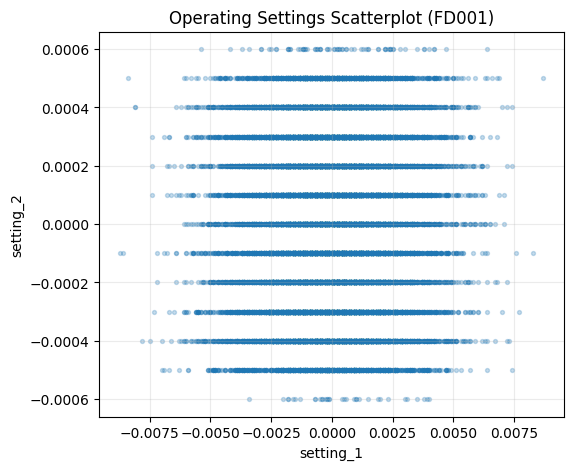

In [26]:
plt.figure(figsize=(6, 5))

plt.scatter(
    df_train["setting_1"],
    df_train["setting_2"],
    alpha=0.25,
    s=8
)

plt.xlabel("setting_1")
plt.ylabel("setting_2")
plt.title(f"Operating Settings Scatterplot ({CURRENT_DATASET})")
plt.grid(True, alpha=0.25)

plt.show()

The operational settings in FD001 show only limited variability. `setting_3` is constant, while `setting_1` and `setting_2` vary only slightly around zero. This supports the dataset description that FD001 contains one operating condition.

Because operating conditions are mostly stable in FD001, sensor changes are easier to interpret as degradation-related patterns. For FD002 and FD004, operating-condition effects would need to be analyzed more carefully because multiple operating regimes can influence sensor values independently of degradation.

# Fast vs. Slow Degrading Engines
Engines in the training set have different total lifetimes. Short-lived engines can be interpreted as faster degrading units, while long-lived engines show slower degradation trajectories. This section compares representative engines from both groups.

In [27]:
engine_lifetimes = (
    df_train_rul
    .groupby("engine")["cycle"]
    .max()
    .reset_index()
    .rename(columns={"cycle": "lifetime_cycles"})
)

engine_lifetimes.sort_values("lifetime_cycles").head()

,engine,lifetime_cycles
38,39,128
90,91,135
69,70,137
56,57,137
57,58,147


In [28]:
N_ENGINES = 3

fast_degrading_engines = (
    engine_lifetimes
    .nsmallest(N_ENGINES, "lifetime_cycles")["engine"]
    .tolist()
)

slow_degrading_engines = (
    engine_lifetimes
    .nlargest(N_ENGINES, "lifetime_cycles")["engine"]
    .tolist()
)

fast_degrading_engines, slow_degrading_engines

([39, 91, 57], [69, 92, 96])

In [29]:
degradation_group_summary = engine_lifetimes.copy()

degradation_group_summary["degradation_group"] = "other"
degradation_group_summary.loc[
    degradation_group_summary["engine"].isin(fast_degrading_engines),
    "degradation_group"
] = "fast"
degradation_group_summary.loc[
    degradation_group_summary["engine"].isin(slow_degrading_engines),
    "degradation_group"
] = "slow"

degradation_group_summary[
    degradation_group_summary["degradation_group"] != "other"
].sort_values(["degradation_group", "lifetime_cycles"])

,engine,lifetime_cycles,degradation_group
38,39,128,fast
90,91,135,fast
56,57,137,fast
95,96,336,slow
91,92,341,slow
68,69,362,slow


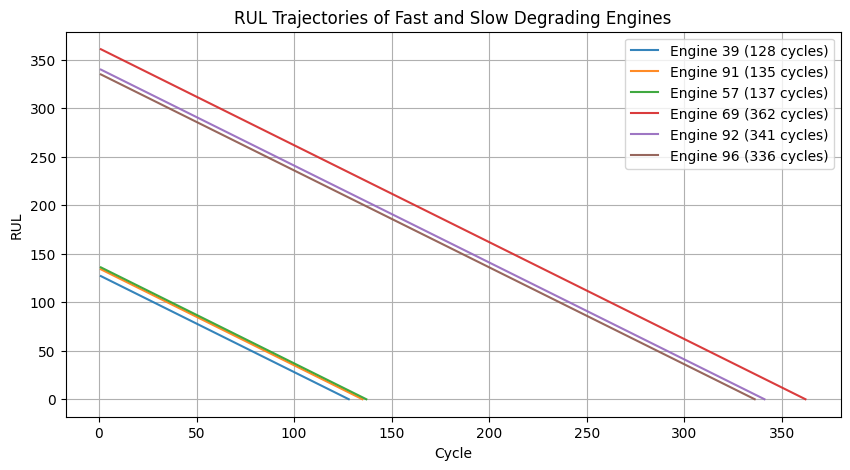

In [30]:
selected_engines = fast_degrading_engines + slow_degrading_engines

plt.figure(figsize=(10, 5))

for engine in selected_engines:
    engine_data = df_train_rul[df_train_rul["engine"] == engine]
    label = (
        f"Engine {engine} "
        f"({engine_data['cycle'].max()} cycles)"
    )
    
    plt.plot(
        engine_data["cycle"],
        engine_data["RUL"],
        alpha=0.9,
        linewidth=1.5,
        label=label
    )

plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title("RUL Trajectories of Fast and Slow Degrading Engines")
plt.legend()
plt.grid(True)
plt.show()

A direct RUL-over-cycle plot is not very informative because RUL is defined as a linear function of the remaining cycles in the training set. Therefore, the comparison focuses on engine lifetime lengths and sensor trajectories instead.

In [31]:
selected_sensors = [
    "T30 (HPC outlet temperature)",
    "T50 (LPT outlet temperature)",
    "Nc (Physical core speed)",
    "NRc (Corrected core speed)"
]

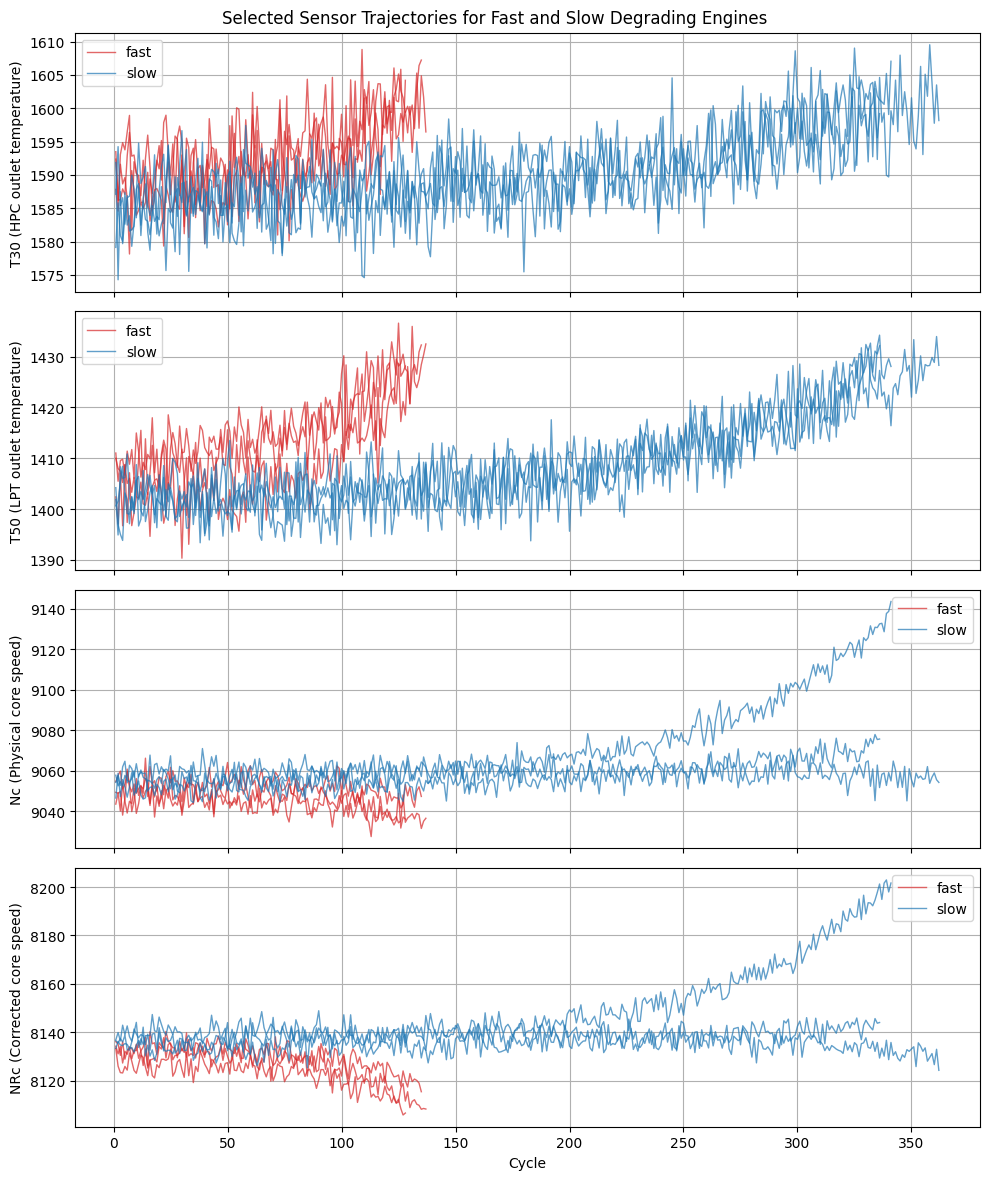

In [32]:
fig, axes = plt.subplots(
    len(selected_sensors),
    1,
    figsize=(10, 3 * len(selected_sensors)),
    sharex=True
)

for ax, sensor in zip(axes, selected_sensors):
    for engine in fast_degrading_engines:
        engine_data = df_train_rul[df_train_rul["engine"] == engine]
        ax.plot(
            engine_data["cycle"],
            engine_data[sensor],
            color="tab:red",
            alpha=0.7,
            linewidth=1,
            label="fast" if engine == fast_degrading_engines[0] else None
        )
    
    for engine in slow_degrading_engines:
        engine_data = df_train_rul[df_train_rul["engine"] == engine]
        ax.plot(
            engine_data["cycle"],
            engine_data[sensor],
            color="tab:blue",
            alpha=0.7,
            linewidth=1,
            label="slow" if engine == slow_degrading_engines[0] else None
        )
    
    ax.set_ylabel(sensor)
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel("Cycle")
fig.suptitle("Selected Sensor Trajectories for Fast and Slow Degrading Engines")
plt.tight_layout()
plt.show()

In [33]:
df_train_rul_normalized = df_train_rul.copy()

df_train_rul_normalized["life_fraction"] = (
    df_train_rul_normalized["cycle"] / df_train_rul_normalized["max_cycle"]
)


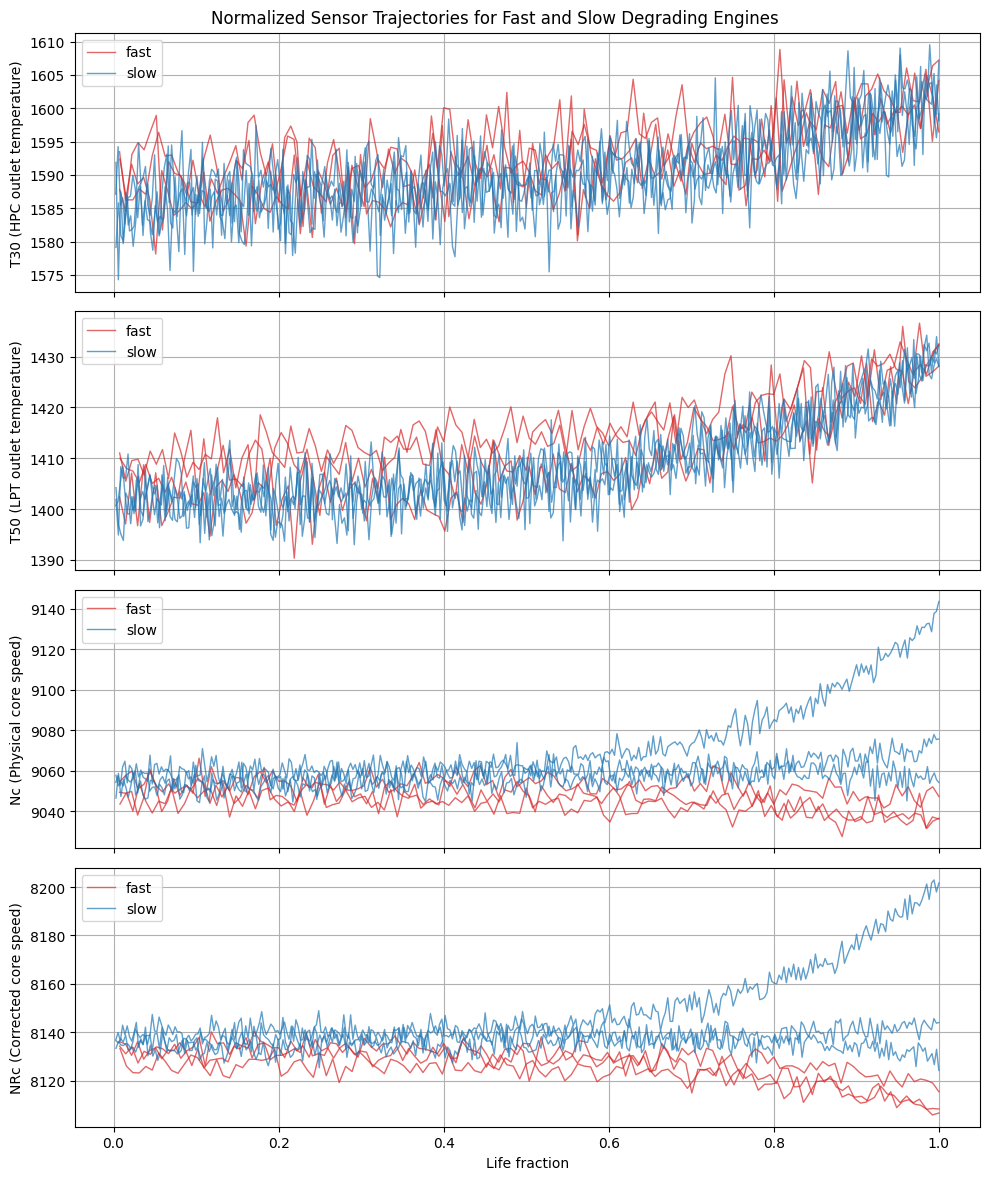

In [34]:
fig, axes = plt.subplots(
    len(selected_sensors),
    1,
    figsize=(10, 3 * len(selected_sensors)),
    sharex=True
)

for ax, sensor in zip(axes, selected_sensors):
    for engine in fast_degrading_engines:
        engine_data = df_train_rul_normalized[
            df_train_rul_normalized["engine"] == engine
        ]
        ax.plot(
            engine_data["life_fraction"],
            engine_data[sensor],
            color="tab:red",
            alpha=0.7,
            linewidth=1,
            label="fast" if engine == fast_degrading_engines[0] else None
        )
    
    for engine in slow_degrading_engines:
        engine_data = df_train_rul_normalized[
            df_train_rul_normalized["engine"] == engine
        ]
        ax.plot(
            engine_data["life_fraction"],
            engine_data[sensor],
            color="tab:blue",
            alpha=0.7,
            linewidth=1,
            label="slow" if engine == slow_degrading_engines[0] else None
        )
    
    ax.set_ylabel(sensor)
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel("Life fraction")
fig.suptitle("Normalized Sensor Trajectories for Fast and Slow Degrading Engines")
plt.tight_layout()
plt.show()

The selected short-lived and long-lived engines show different total lifetimes, but all trajectories follow the same general RUL definition: RUL decreases toward zero as failure approaches.

Comparing sensor trajectories over raw cycle count highlights differences in absolute lifetime length. Normalizing cycle count by each engine's maximum lifetime makes degradation patterns more comparable across engines.

Sensors such as `T30`, `T50`, `Nc` and `NRc` are useful candidates for this comparison because they showed non-constant behavior and relatively high variability in the previous analysis.

# Feature Correlations

In [35]:
correlation_data = df_train_rul_non_constant.drop(
    columns=["engine", "max_cycle"],
    errors="ignore"
)

correlation_matrix = correlation_data.corr()

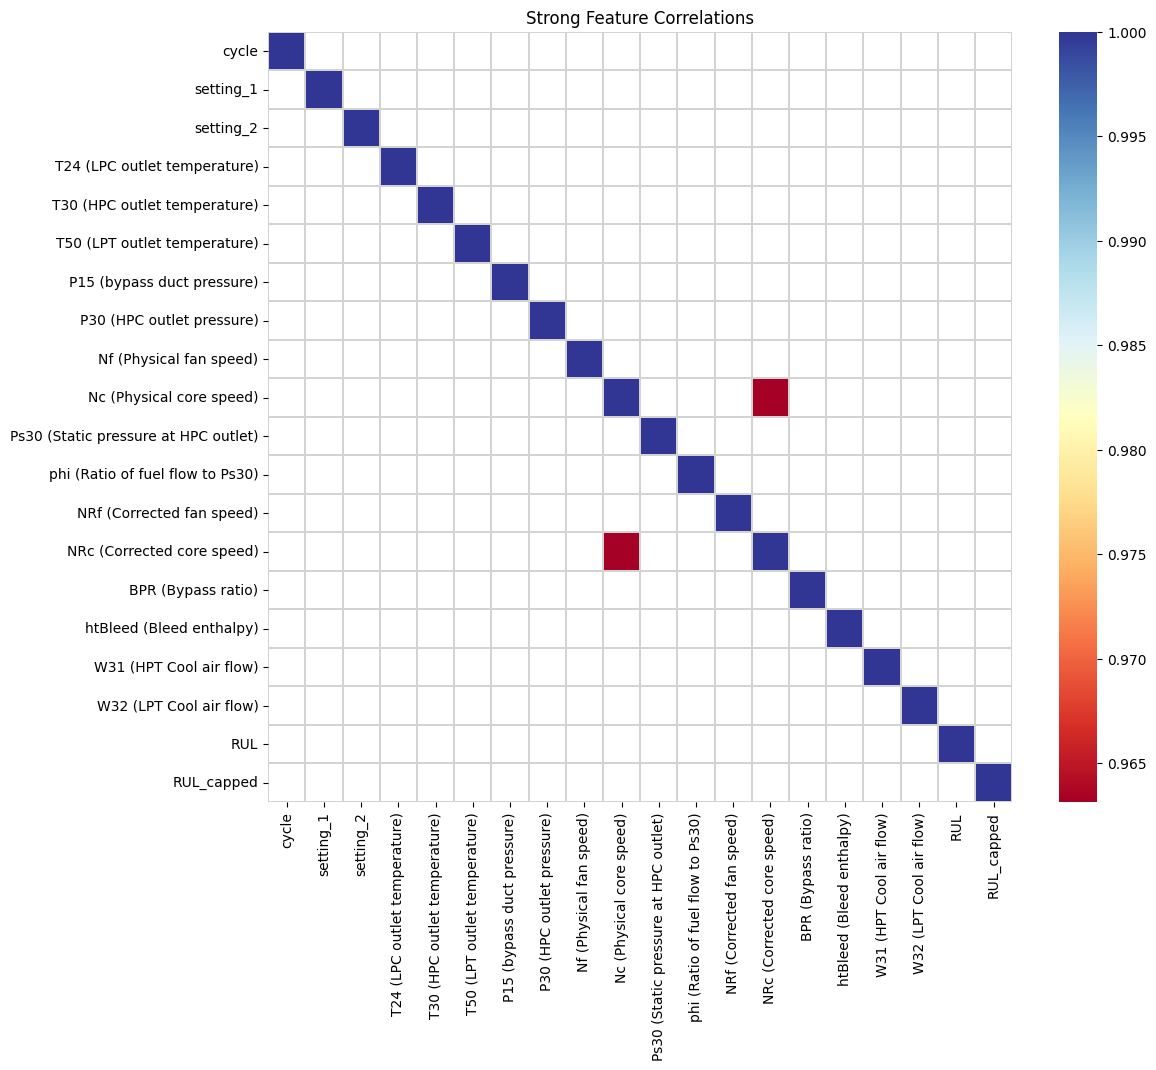

In [36]:
plt.figure(figsize=(12, 10))

threshold = 0.90
mask = correlation_matrix.where(
    correlation_matrix.abs() >= threshold
).isna()

sns.heatmap(
    correlation_matrix,
    cmap="RdYlBu",
    annot=False,
    mask=mask,
    linewidths=0.2,
    linecolor="lightgrey"
)

plt.title("Strong Feature Correlations")
plt.show()

In [37]:
available_sensors = [
    sensor for sensor in SENSOR_NAMES
    if sensor in df_train_rul_non_constant.columns
]

sensor_rul_correlations = (
    df_train_rul_non_constant[available_sensors + ["RUL", "RUL_capped"]]
    .corr()[["RUL", "RUL_capped"]]
    .drop(index=["RUL", "RUL_capped"], errors="ignore")
)

sensor_rul_correlations["abs_RUL_capped_correlation"] = (
    sensor_rul_correlations["RUL_capped"].abs()
)

sensor_rul_correlations = sensor_rul_correlations.sort_values(
    "abs_RUL_capped_correlation",
    ascending=False
)

sensor_rul_correlations

,RUL,RUL_capped,abs_RUL_capped_correlation
Ps30 (Static pressure at HPC outlet),-0.696228,-0.775230,0.775230
T50 (LPT outlet temperature),-0.678948,-0.757157,0.757157
phi (Ratio of fuel flow to Ps30),0.671983,0.748870,0.748870
P30 (HPC outlet pressure),0.657223,0.733021,0.733021
BPR (Bypass ratio),-0.642667,-0.720858,0.720858
W32 (LPT Cool air flow),0.635662,0.707334,0.707334
W31 (HPT Cool air flow),0.629428,0.704626,0.704626
htBleed (Bleed enthalpy),-0.606154,-0.680829,0.680829
T24 (LPC outlet temperature),-0.606484,-0.678458,0.678458
T30 (HPC outlet temperature),-0.584520,-0.655030,0.655030


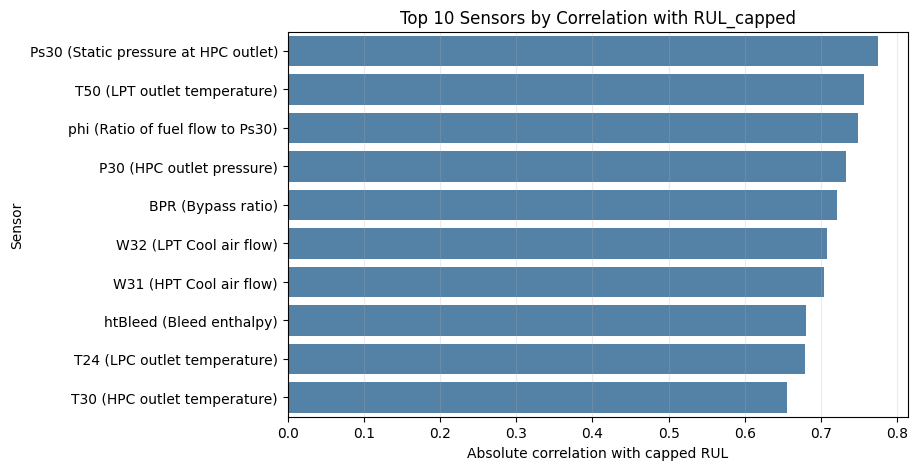

In [38]:
top_n = 10

top_sensor_correlations = sensor_rul_correlations.head(top_n)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_sensor_correlations.reset_index().rename(columns={"index": "sensor"}),
    x="abs_RUL_capped_correlation",
    y="sensor",
    color="steelblue"
)

plt.xlabel("Absolute correlation with capped RUL")
plt.ylabel("Sensor")
plt.title(f"Top {top_n} Sensors by Correlation with RUL_capped")
plt.grid(axis="x", alpha=0.25)

plt.show()

The correlation analysis highlights sensors that show a strong linear relationship with the RUL target. These sensors are useful first candidates for feature engineering and trajectory visualization.

However, correlation only captures linear relationships and does not imply causal relevance. Some sensors may still be important through non-linear interactions or temporal trends that are not visible in simple correlation coefficients.

The strongest absolute correlations with `RUL_capped` are observed for sensors such as `Ps30`, `T50` and `phi`. These sensors should be inspected more closely in trajectory plots and later included in feature engineering.

# Sensor Trajectory Analysis

This section visualizes selected sensor trajectories over the engine lifetime. The selected sensors are non-constant and showed relevant variability or correlation with the RUL target in previous analyses.

In [39]:
selected_sensors = sensor_rul_correlations.head(4).index.tolist()
selected_sensors

['Ps30 (Static pressure at HPC outlet)',
 'T50 (LPT outlet temperature)',
 'phi (Ratio of fuel flow to Ps30)',
 'P30 (HPC outlet pressure)']

In [40]:
selected_engines = fast_degrading_engines + slow_degrading_engines
selected_engines

[39, 91, 57, 69, 92, 96]

In [41]:
df_train_rul_normalized = df_train_rul.copy()

df_train_rul_normalized["life_fraction"] = (
    df_train_rul_normalized["cycle"]
    / df_train_rul_normalized["max_cycle"]
)

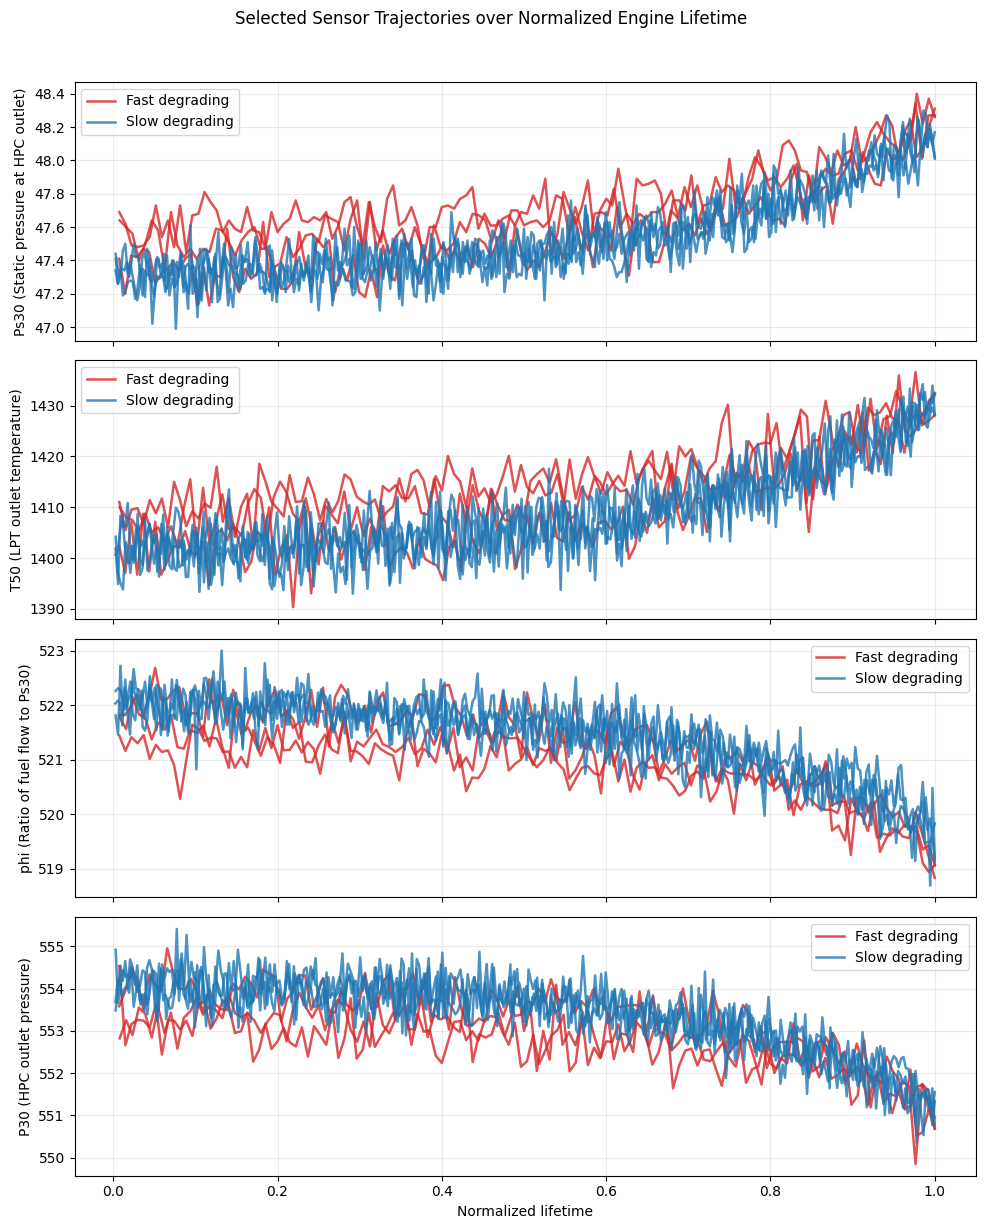

In [42]:
fig, axes = plt.subplots(
    len(selected_sensors),
    1,
    figsize=(10, 3 * len(selected_sensors)),
    sharex=True
)

for ax, sensor in zip(axes, selected_sensors):
    for engine in fast_degrading_engines:
        engine_data = df_train_rul_normalized[
            df_train_rul_normalized["engine"] == engine
        ]
        ax.plot(
            engine_data["life_fraction"],
            engine_data[sensor],
            color="tab:red",
            linewidth=1.8,
            alpha=0.8,
            label="Fast degrading" if engine == fast_degrading_engines[0] else None
        )
    
    for engine in slow_degrading_engines:
        engine_data = df_train_rul_normalized[
            df_train_rul_normalized["engine"] == engine
        ]
        ax.plot(
            engine_data["life_fraction"],
            engine_data[sensor],
            color="tab:blue",
            linewidth=1.8,
            alpha=0.8,
            label="Slow degrading" if engine == slow_degrading_engines[0] else None
        )
    
    ax.set_ylabel(sensor)
    ax.grid(True, alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("Normalized lifetime")
fig.suptitle("Selected Sensor Trajectories over Normalized Engine Lifetime", y=1.02)

plt.tight_layout()
plt.show()

In [43]:
df_train_rul_normalized["life_bin"] = pd.cut(
    df_train_rul_normalized["life_fraction"],
    bins=np.linspace(0, 1, 21),
    include_lowest=True
)

In [44]:
df_train_rul_normalized["degradation_group"] = "other"

df_train_rul_normalized.loc[
    df_train_rul_normalized["engine"].isin(fast_degrading_engines),
    "degradation_group"
] = "fast"

df_train_rul_normalized.loc[
    df_train_rul_normalized["engine"].isin(slow_degrading_engines),
    "degradation_group"
] = "slow"

In [45]:
trajectory_summary = (
    df_train_rul_normalized[
        df_train_rul_normalized["degradation_group"].isin(["fast", "slow"])
    ]
    .groupby(["degradation_group", "life_bin"], observed=True)[selected_sensors]
    .mean()
    .reset_index()
)

trajectory_summary["life_bin_mid"] = trajectory_summary["life_bin"].apply(
    lambda interval: interval.mid
)

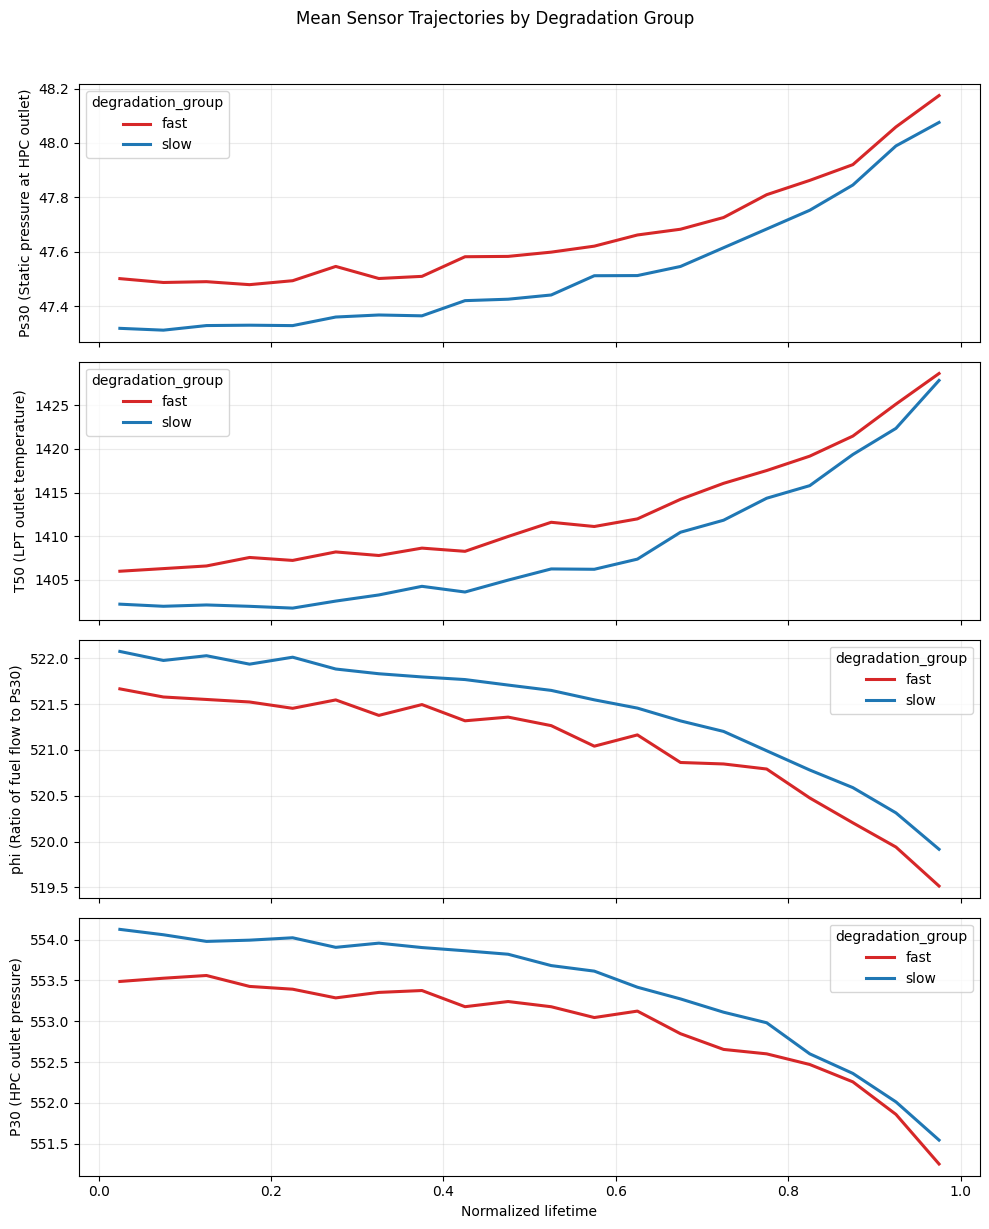

In [46]:
fig, axes = plt.subplots(
    len(selected_sensors),
    1,
    figsize=(10, 3 * len(selected_sensors)),
    sharex=True
)

for ax, sensor in zip(axes, selected_sensors):
    sns.lineplot(
        data=trajectory_summary,
        x="life_bin_mid",
        y=sensor,
        hue="degradation_group",
        ax=ax,
        linewidth=2.2,
        palette={
            "fast": "tab:red",
            "slow": "tab:blue"
        }
    )
    
    ax.set_ylabel(sensor)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("Normalized lifetime")
fig.suptitle("Mean Sensor Trajectories by Degradation Group", y=1.02)

plt.tight_layout()
plt.show()

The selected sensor trajectories show how degradation-related signals evolve over the normalized engine lifetime. Normalizing by each engine's maximum cycle makes short-lived and long-lived engines comparable on the same time scale.

The grouped mean trajectories reduce visual noise and highlight systematic differences between fast and slow degrading engines. These sensors are therefore useful candidates for later feature engineering and model input selection.

## Optional Plot for Sensor Analysis

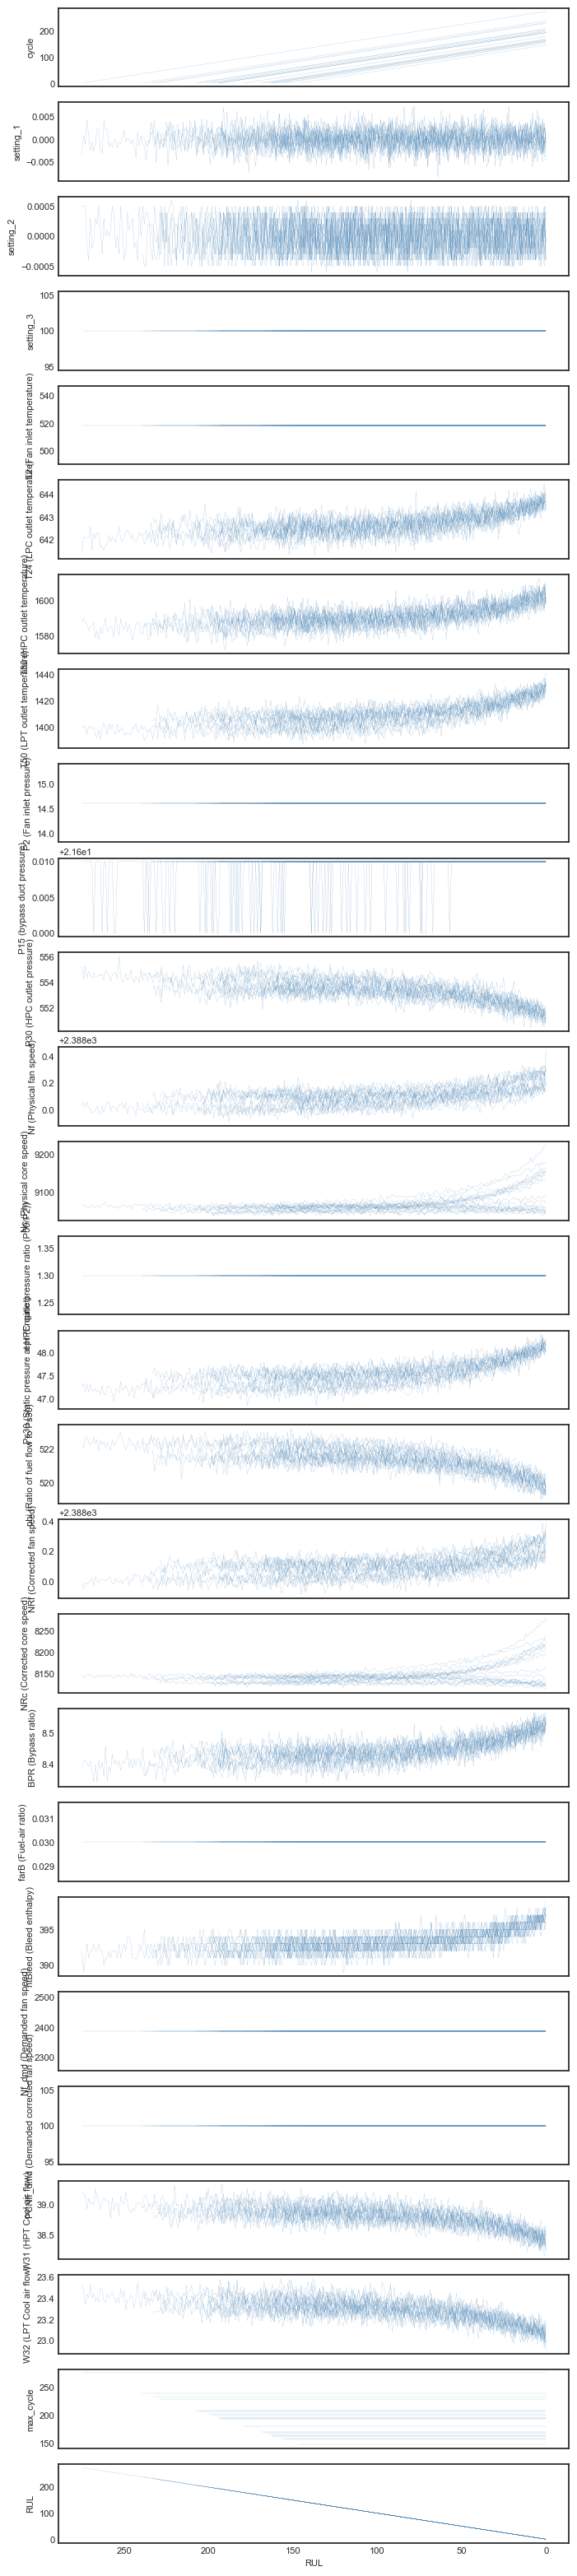

In [47]:
plt.style.use("seaborn-v0_8-white") 
plt.rcParams['figure.figsize']=8,40 
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 8
plt.rcParams['lines.linewidth'] = 0.1
plot_items = list(df_train_rul.columns)[1:-1]
fig,ax = plt.subplots(len(plot_items),sharex=True)
ax[0].invert_xaxis()

engines = list(df_train_rul['engine'].unique())

for engine in engines[10:30]:
    for i,item in enumerate(plot_items):
        f = sns.lineplot(data=df_train_rul[df_train_rul['engine']==engine],x='RUL',y=item,color='steelblue',ax=ax[i],
                        )


# EDA Takeaways

The exploratory analysis confirms that FD001 is a suitable starting point for developing an initial RUL prediction pipeline. The subset contains one operating condition and one fault mode, which reduces the complexity of the degradation analysis compared with FD002 and FD004.

The training trajectories represent complete run-to-failure sequences. Therefore, the maximum observed cycle of each engine can be used to construct the RUL target. A capped RUL target is useful for later modeling because early-life degradation is often assumed to be weak or not directly observable.

Several features are constant within FD001, including one operational setting and multiple sensor signals. These features are unlikely to provide useful degradation information and should be considered for removal during preprocessing. Low-variance signals should also be treated carefully, although they are not automatically irrelevant.

The engine lifetime analysis shows that engines fail after different numbers of cycles. This motivates comparing short-lived and long-lived engines to better understand degradation behavior across units.

The operational settings in FD001 show only limited variability, supporting the dataset description that FD001 contains one operating condition. This makes FD001 easier to interpret than subsets with multiple operating regimes.

The correlation and trajectory analyses provide first sensor candidates for later feature engineering. Sensors with strong variation, visible degradation trends, or high correlation with the RUL target should be prioritized in subsequent preprocessing and modeling steps.

The next notebook should transform these EDA findings into a reproducible preprocessing pipeline, including feature removal, RUL target preparation, scaling decisions and train-validation splitting by engine unit.